In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,roc_curve,auc
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import RobustScaler

X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")

y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test = pd.read_csv("../data/y_test.csv").squeeze()

X=pd.read_csv("../data/X.csv")
y=pd.read_csv("../data/y.csv").squeeze()


In [5]:
X.shape


(19368, 8)

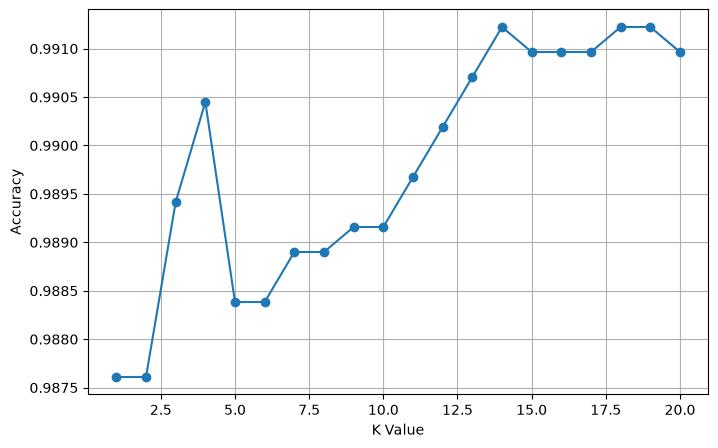

In [7]:
accuracy_list = []

k_values = range(1,21)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k , weights='distance')
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    score = accuracy_score(y_test,pred)
    accuracy_list.append(score)

plt.figure(figsize=(8,5))
plt.plot(k_values, accuracy_list, marker="o")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

In [ ]:
knn = KNeighborsClassifier(n_neighbors = 14, weights='distance')
knn.fit(X_train,y_train)
y_pred = knn.predict(X_test)
knn.score(X_test,y_test)

0.9912235415591121

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1112
           1       0.99      0.99      0.99      2762

    accuracy                           0.99      3874
   macro avg       0.99      0.99      0.99      3874
weighted avg       0.99      0.99      0.99      3874



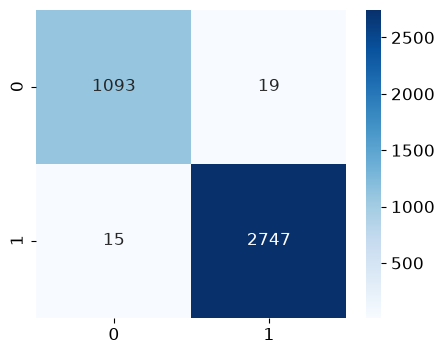

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d"
)
plt.show()

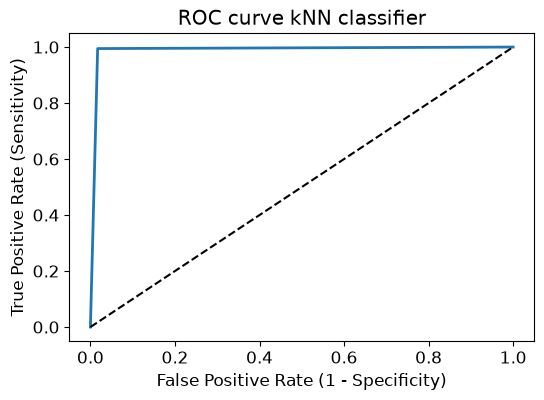

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, linewidth=2)

plt.plot([0,1], [0,1], 'k--' )

plt.rcParams['font.size'] = 12

plt.title('ROC curve kNN classifier')

plt.xlabel('False Positive Rate (1 - Specificity)')

plt.ylabel('True Positive Rate (Sensitivity)')

plt.show()

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

y_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)

results = pd.DataFrame({
    "Model": ["KNN"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1 Score": [f1],
    "ROC AUC": [roc_auc]
})

results.to_csv("../results/KNN_results.csv", index=False)

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "../results/KNN_classification_report.csv"
)

In [ ]:
scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)
gnb.score(X_test, y_test)


0.573309241094476

In [ ]:
print(classification_report(y_test, y_pred_gnb))

              precision    recall  f1-score   support

           0       0.40      0.96      0.56      1112
           1       0.96      0.42      0.58      2762

    accuracy                           0.57      3874
   macro avg       0.68      0.69      0.57      3874
weighted avg       0.80      0.57      0.58      3874



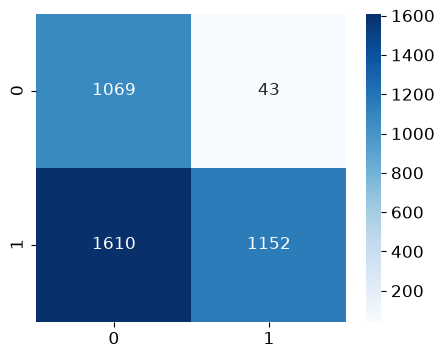

In [ ]:
cm_gnb = confusion_matrix(y_test, y_pred_gnb)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_gnb,
    annot=True,
    cmap="Blues",
    fmt="d"
)
plt.show()

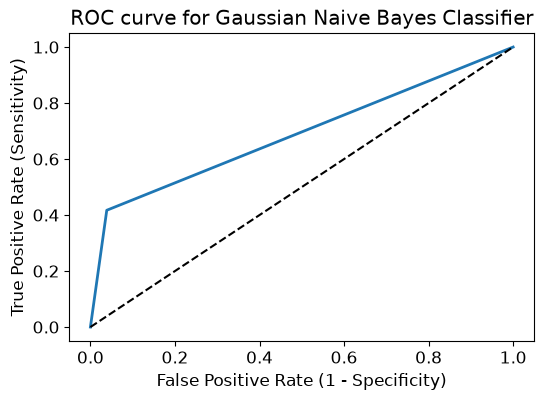

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_gnb)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, linewidth=2)

plt.plot([0,1], [0,1], 'k--' )

plt.rcParams['font.size'] = 12

plt.title('ROC curve for Gaussian Naive Bayes Classifier')

plt.xlabel('False Positive Rate (1 - Specificity)')

plt.ylabel('True Positive Rate (Sensitivity)')

plt.show()
